In [42]:
# Name: Eshwar Lal 
# Student ID: 023-24-0186
# Section: F
# Github Profile: https://github.com/Eshwarlal-125/Machine_Learning_Course
# Kaggle Profile: https://www.kaggle.com/mreshwar
# Dataset: Telco Customer Churn Dataset
# Dataset Source: Kaggle — Telco Customer Churn Dataset

In [43]:
# Task: 1 Re-load your cleaned Lab 2 dataset and recreate the same X/y and train/test split you used in Lab 3 (same random_state).
import pandas as pd
dataset = pd.read_csv("clean_churn.csv")
y = dataset["Churn"].map({"No": 0, "Yes": 1})
X = dataset.drop(columns=["Churn"])
X = pd.get_dummies(X, dtype=int)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Dataset shape:", dataset.shape)
print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

Dataset shape: (7043, 20)
X shape: (7043, 45)
y shape: (7043,)
X_train: (5634, 45)
X_test: (1409, 45)
y_train: (5634,)
y_test: (1409,)


In [ ]:
# Task: 2 Retrain your Lab 3 "best" Decision Tree (your chosen max_depth) and report its accuracy, precision, recall, and F1-score on the test set. This is your benchmark for the rest of the lab.
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
decision_tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)
decision_tree_model.fit(X_train, y_train)
decision_tree_pred = decision_tree_model.predict(X_test)
decision_tree_accuracy = accuracy_score(y_test, decision_tree_pred)
decision_tree_precision = precision_score(y_test, decision_tree_pred)
decision_tree_recall = recall_score(y_test, decision_tree_pred)
decision_tree_f1 = f1_score(y_test, decision_tree_pred)
print("Decision Tree Baseline")
print("Accuracy:", decision_tree_accuracy)
print("Precision:", decision_tree_precision)
print("Recall:", decision_tree_recall)
print("F1-score:", decision_tree_f1)

# Interpretation: The Decision Tree achieved about 79.84% accuracy and an F1-score of 59.89% 
# on the test set. This provides a baseline for comparing the Random Forest models.

Decision Tree Baseline
Accuracy: 0.7984386089425124
Precision: 0.6347305389221557
Recall: 0.5668449197860963
F1-score: 0.5988700564971752


In [45]:
# Task: 3 Train a RandomForestClassifier on the same training data (reasonable default n_estimators, e.g. 100–300; fix random_state). Generate predictions on the test set.
from sklearn.ensemble import RandomForestClassifier
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
random_forest_model.fit(X_train, y_train)
random_forest_pred = random_forest_model.predict(X_test)
print("Random Forest predictions generated successfully.")

Random Forest predictions generated successfully.


In [46]:
# Task:4 In 1–2 sentences, explain in your own words why a Random Forest might generalize better than a single unrestricted Decision Tree.


# Random Forest combines many decision trees and averages their predictions, 
# which reduces overfitting. Therefore, it can generalize better to unseen data than a 
# single unrestricted Decision Tree.

In [ ]:
# Task: 5 Compute accuracy, precision, recall, and F1-score for the Random Forest on the test set, and plot its confusion matrix.
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
random_forest_accuracy = accuracy_score(y_test, random_forest_pred)
random_forest_precision = precision_score(y_test, random_forest_pred)
random_forest_recall = recall_score(y_test, random_forest_pred)
random_forest_f1 = f1_score(y_test, random_forest_pred)
random_forest_cm = confusion_matrix(y_test, random_forest_pred)
print("Random Forest Performance")
print("Accuracy:", random_forest_accuracy)
print("Precision:", random_forest_precision)
print("Recall:", random_forest_recall)
print("F1-score:", random_forest_f1)

print("\nConfusion Matrix:")
print(random_forest_cm)

# Interpretation: The default Random Forest achieved 78.57% accuracy and an F1-score of 54.65%. 
# The confusion matrix shows how well the model identifies both churn and non-churn customers.

Random Forest Performance
Accuracy: 0.7856635911994322
Precision: 0.6232876712328768
Recall: 0.48663101604278075
F1-score: 0.5465465465465466

Confusion Matrix:
[[925 110]
 [192 182]]


In [ ]:
# Task: 6 Build a single comparison table: Decision Tree (Part 1) vs. Random Forest (Part 2), across all four metrics.
comparison_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Decision Tree": [
        decision_tree_accuracy,
        decision_tree_precision,
        decision_tree_recall,
        decision_tree_f1
    ],
    "Random Forest": [
        random_forest_accuracy,
        random_forest_precision,
        random_forest_recall,
        random_forest_f1
    ]
})
comparison_table

# Interpretation: The Decision Tree performs better than the default Random Forest across all 
# four test metrics, especially in recall and F1-score.

,Metric,Decision Tree,Random Forest
0,Accuracy,0.798439,0.785664
1,Precision,0.634731,0.623288
2,Recall,0.566845,0.486631
3,F1-score,0.598870,0.546547


In [49]:
# Task: 7 Which model performs better, and on which specific metric(s)? Is the difference large or marginal? Given Lab 2/3's finding about class imbalance, which metric matters most here?

# The Decision Tree performs better than the Random Forest on all four evaluation metrics. 
# The Decision Tree has higher accuracy, precision, recall, and F1-score.
# The differences are relatively small for accuracy and precision, but the difference in recall 
# is more noticeable. Since the dataset has class imbalance, recall and F1-score are important 
# because they help evaluate how well the model identifies customers who are likely to churn.
# Therefore, for this comparison, recall and F1-score should be given more attention rather
# than relying only on accuracy.

In [50]:
# Task: 8 Run 5-fold cross-validation for both the Decision Tree and the Random Forest, using a metric other than plain accuracy (e.g. F1-score). Report the mean and standard deviation of each model's fold scores.

from sklearn.model_selection import cross_val_score
decision_tree_cv = cross_val_score(
    decision_tree_model,
    X,
    y,
    cv=5,
    scoring="f1"
)
random_forest_cv = cross_val_score(
    random_forest_model,
    X,
    y,
    cv=5,
    scoring="f1"
)
print("Decision Tree CV F1-scores:", decision_tree_cv)
print("Decision Tree Mean F1:", decision_tree_cv.mean())
print("Decision Tree Std:", decision_tree_cv.std())
print("\nRandom Forest CV F1-scores:", random_forest_cv)
print("Random Forest Mean F1:", random_forest_cv.mean())
print("Random Forest Std:", random_forest_cv.std())

# The Decision Tree achieved a higher mean cross-validation F1-score (0.5994) than the 
# Random Forest (0.5463). The standard deviations are relatively small, showing that the 
# F1-scores are fairly consistent across the five folds.

Decision Tree CV F1-scores: [0.61246612 0.62382865 0.59259259 0.5907781  0.57720058]
Decision Tree Mean F1: 0.5993732080724318
Decision Tree Std: 0.016619092795368173

Random Forest CV F1-scores: [0.56752656 0.54545455 0.50822123 0.5482866  0.56183206]
Random Forest Mean F1: 0.5462641983963167
Random Forest Std: 0.020719361030532266


In [51]:
# Task: 9 How do the cross-validated results compare to your single train/test split results from Part 3? Do they change your view of which model is better, or how confident you are in that conclusion?


# The cross-validation results are very close to the single train/test split results. 
# The Decision Tree has an F1-score of 0.5989 on the test set and a mean CV F1-score of 0.5994, 
# while the Random Forest has 0.5465 and 0.5463 respectively. This consistency increases confidence 
# that the results are not strongly dependent on one particular train/test split.

In [52]:
# Task: 10 Choose 2–3 Random Forest hyperparameters to tune (e.g. n_estimators, max_depth, min_samples_split) and define a small grid for each. Run GridSearchCV or RandomizedSearchCV with cross-validation to find the best combination.

from sklearn.model_selection import GridSearchCV
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5]
}
grid_search_cv = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)
grid_search_cv.fit(X_train, y_train)
print("Best Parameters:", grid_search_cv.best_params_)
print("Best CV F1-score:", grid_search_cv.best_score_)

Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best CV F1-score: 0.5744532996926232


In [53]:
# Task: 11 Report the best hyperparameters found and the corresponding cross-validated score.

# The best hyperparameters found by GridSearchCV are:
# - n_estimators = 200
# - max_depth = 10
# - min_samples_split = 5
# The best cross-validation F1-score is 0.5745.

In [ ]:
# Task: 12 Evaluate the tuned model on the held-out test set using the same four metrics as before.

tuned_random_forest_model = grid_search_cv.best_estimator_
tuned_random_forest_pred = tuned_random_forest_model.predict(X_test)
tuned_random_forest_accuracy = accuracy_score(
    y_test, tuned_random_forest_pred
)
tuned_random_forest_precision = precision_score(
    y_test, tuned_random_forest_pred
)
tuned_random_forest_recall = recall_score(
    y_test, tuned_random_forest_pred
)
tuned_random_forest_f1 = f1_score(
    y_test, tuned_random_forest_pred
)
print("Tuned Random Forest Performance")
print("Accuracy:", tuned_random_forest_accuracy)
print("Precision:", tuned_random_forest_precision)
print("Recall:", tuned_random_forest_recall)
print("F1-score:", tuned_random_forest_f1)

# Interpretation: The tuned Random Forest achieved 80.62% accuracy, 67.00% precision, 
# 53.21% recall, and 59.31% F1-score on the test set.

Tuned Random Forest Performance
Accuracy: 0.8062455642299503
Precision: 0.67003367003367
Recall: 0.5320855614973262
F1-score: 0.5931445603576752


In [ ]:
# Task: 13 Build one final comparison table across all models you trained: Decision Tree, default Random Forest, and tuned Random Forest — accuracy, precision, recall, F1-score for each.

final_comparison_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Decision Tree": [
        decision_tree_accuracy,
        decision_tree_precision,
        decision_tree_recall,
        decision_tree_f1
    ],
    "Default Random Forest": [
        random_forest_accuracy,
        random_forest_precision,
        random_forest_recall,
        random_forest_f1
    ],
    "Tuned Random Forest": [
        tuned_random_forest_accuracy,
        tuned_random_forest_precision,
        tuned_random_forest_recall,
        tuned_random_forest_f1
    ]
})

final_comparison_table

# Interpretation: The Tuned Random Forest achieved the highest accuracy and precision, 
# while the Decision Tree achieved slightly higher recall and F1-score.

,Metric,Decision Tree,Default Random Forest,Tuned Random Forest
0,Accuracy,0.798439,0.785664,0.806246
1,Precision,0.634731,0.623288,0.670034
2,Recall,0.566845,0.486631,0.532086
3,F1-score,0.598870,0.546547,0.593145


In [56]:
# Task: 14 Select your final model and justify the choice in 2–3 sentences using evidence from the table above — the best training score alone is not sufficient justification.


# I select the Tuned Random Forest as the final model because it achieved the highest test 
# accuracy (80.62%) and precision (67.00%) among the three models. Its F1-score (59.31%) is 
# also close to the Decision Tree (59.89%), while its recall (53.21%) is lower than the Decision
# Tree (56.68%). The selection is based on the overall test performance rather than training score
# alone.

In [57]:
# Task: 15 Extract and visualize feature_importances_ for your final model. Which 3–5 features matter most, and do they agree with what Lab 2's EDA and Lab 3's Decision Tree suggested?

import pandas as pd
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": tuned_random_forest_model.feature_importances_
})
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)
feature_importance.head(10)

,Feature,Importance
1,tenure,0.148127
3,TotalCharges,0.120379
36,Contract_Month-to-month,0.093459
2,MonthlyCharges,0.084836
18,OnlineSecurity_No,0.055085
27,TechSupport_No,0.047718
16,InternetService_Fiber optic,0.047263
43,PaymentMethod_Electronic check,0.040489
38,Contract_Two year,0.029719
15,InternetService_DSL,0.020474


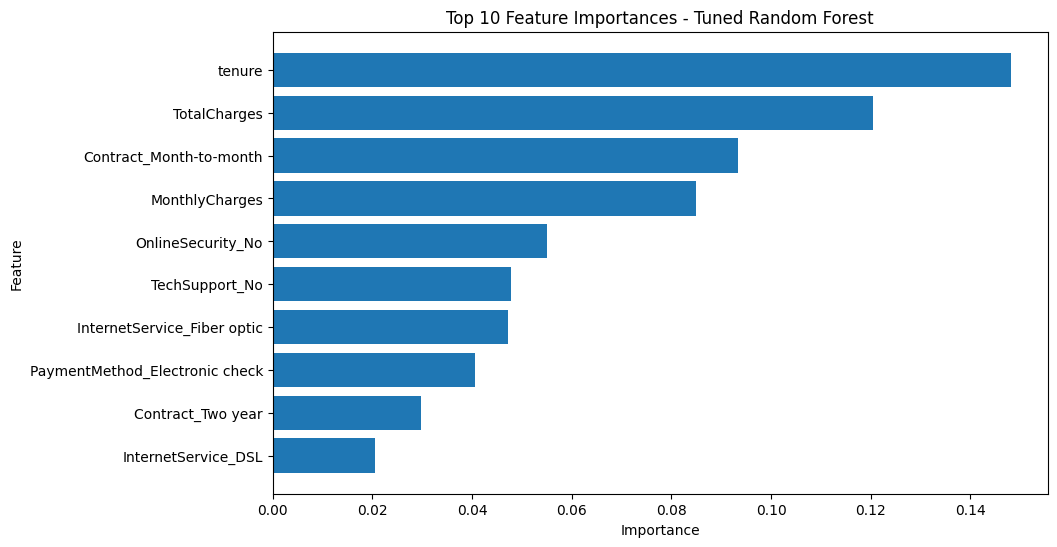

In [58]:
# Continue Task: 15 Visual part (Bar chart)

import matplotlib.pyplot as plt
top_features = feature_importance.head(10)
plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances - Tuned Random Forest")
plt.gca().invert_yaxis()
plt.show()


# The most important features are tenure, TotalCharges, Contract_Month-to-month, MonthlyCharges,
# and OnlineSecurity_No. These results are partly consistent with the previous Decision Tree,
# especially for tenure and contract type.

In [59]:
# Task: 16 Using your final model, generate predictions on your held-out test set (or a designated hold-out sample) and assemble a submission-style dataframe with a customer identifier column and a predicted Churn column. Save it as submission.csv.

original_dataset = pd.read_csv(
    "WA_Fn-UseC_-Telco-Customer-Churn.csv"
)
submission = pd.DataFrame({
    "customerID": original_dataset.loc[X_test.index, "customerID"],
    "Churn": tuned_random_forest_pred
})
submission.to_csv("submission.csv", index=False)
submission.head()

,customerID,Churn
437,4376-KFVRS,0
2280,2754-SDJRD,1
2235,9917-KWRBE,0
4460,0365-GXEZS,0
3761,9385-NXKDA,0


In [60]:
# Task: 17 Write a short conclusion (4–6 sentences): which model did you ultimately choose, how does it compare to your Lab 3 Decision Tree, and what are its remaining limitations?


# I selected the Tuned Random Forest as the final model because it gave good overall performance 
# on the test data. It achieved 80.62% accuracy, 67.00% precision, and a 59.31% F1-score. 
# Compared with the Decision Tree from Lab 3, it performed better in accuracy and precision, 
# while the Decision Tree had slightly better recall and F1-score. Cross-validation and 
# hyperparameter tuning helped me evaluate the model more reliably. However, the model may still 
# miss some customers who are likely to churn.

In [61]:
# Task: 18 What would you try next if you had more time (e.g. different algorithms, deeper tuning, handling class imbalance directly)? Describe it — do not implement it here.


# If I had more time, I would try different machine learning models, improve feature selection, 
# handle class imbalance more carefully, and perform more hyperparameter tuning to improve churn
# prediction.